# Simulación de un Péndulo Simple

Este proyecto modela y simula el comportamiento dinámico de un **péndulo simple** mediante la solución numérica de una ecuación diferencial ordinaria (EDO). Se utiliza integración numérica para analizar la evolución temporal del sistema.

---

## Planteamiento del problema

Un péndulo simple consiste en una masa puntual suspendida de un hilo inextensible y sin masa, bajo la acción de la gravedad.

El sistema se describe mediante la siguiente ecuación diferencial no lineal:

$$
\frac{d^2 \theta}{dt^2} + \frac{g}{l} \sin(\theta) = 0
$$

Donde:

- $\theta(t)$: ángulo del péndulo respecto a la vertical  
- $g$: aceleración de la gravedad  
- $l$: longitud del péndulo  
---

## Reformulación del sistema

Para resolver esta ecuación con métodos numéricos, se transforma en un sistema de primer orden:

$$
\begin{cases}
\frac{d\theta}{dt} = \omega \\
\frac{d\omega}{dt} = -\frac{g}{l} \sin(\theta)
\end{cases}
$$

Donde:
$\omega$: velocidad angular  

---

## Parámetros del modelo

| Parámetro | Valor | Descripción |
|----------|------|------------|
| $g$ | 9.81 m/s² | Gravedad |
| $l$ | 1.0 m | Longitud del péndulo |
| $\theta_0$ | $\frac{\pi}{4}$ | Ángulo inicial |
| $\omega_0$ | 0.0 | Velocidad angular inicial |

---

## Método de solución

Se utiliza la función `odeint` de la librería **SciPy**, que implementa métodos de integración para sistemas de ecuaciones diferenciales ordinarias.

El sistema se evalúa en un intervalo de tiempo de:

$$
t \in [0, 10]
$$

con 100 puntos de discretización.

---

## Resultados

El script genera una gráfica que muestra:

- Evolución del ángulo $\theta(t)$
- Evolución de la velocidad angular $\omega(t)$

Esto permite observar el comportamiento oscilatorio del péndulo y su dinámica no lineal.



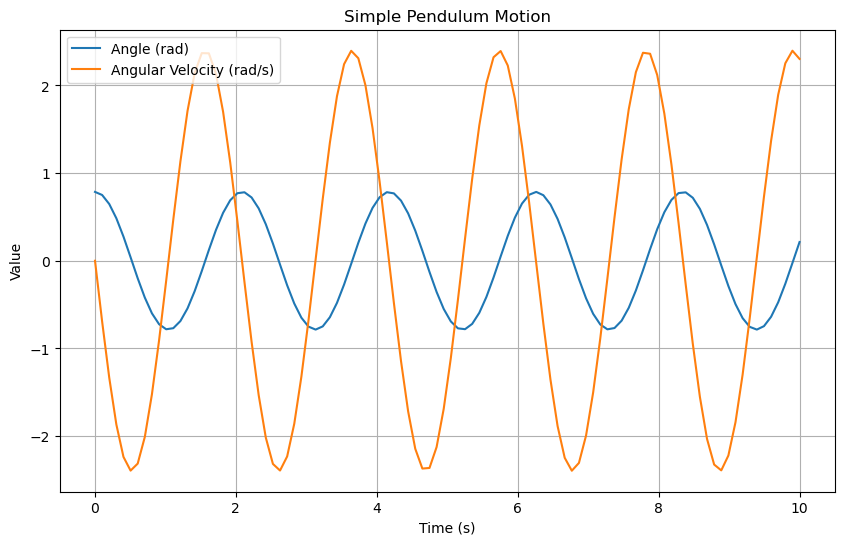

In [3]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Pendulum parameters
g = 9.81  # Acceleration due to gravity (m/s^2)
l = 1.0   # Length of the pendulum (m)

# Initial conditions
theta0 = np.pi / 4  # Initial angle (radians)
omega0 = 0.0       # Initial angular velocity (rad/s)

# Time points for simulation
t_span = (0, 10)  # Time interval (seconds)
t = np.linspace(t_span[0], t_span[1], 100)

# Define the differential equation for the pendulum
def pendulum_equation(y, t, g, l):
  theta, omega = y
  dydt = [omega, - (g / l) * np.sin(theta)]
  return dydt

# Solve the differential equation
sol = odeint(pendulum_equation, [theta0, omega0], t, args=(g, l))

# Extract the angle and angular velocity
theta = sol[:, 0]
omega = sol[:, 1]

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t, theta, label='Angle (rad)')
plt.plot(t, omega, label='Angular Velocity (rad/s)')
plt.xlabel('Time (s)')
plt.ylabel('Value')
plt.title('Simple Pendulum Motion')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.savefig("../Images/pendulum.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>